In [ ]:
import numpy as np
import matplotlib.pyplot as plt


### FHN MODEL : DISCRETIZZAZIONE SEMI IMPLICITA 
## vedi Roger McCulloch per test

# Parametri 
sigma = 0.002
g, beta, delta = 1.5, 0.1, 1
vth, vp = 13, 100
mu1, gamma, mu2 = 4.4, 0.25, 0.012
T = 50
L = 1

n = 101
m = 1000
h = L / n  
tau = 0.05 #ms

alpha = sigma / h**2

x = np.linspace(0, L, n)
t = np.linspace(0, T, m)


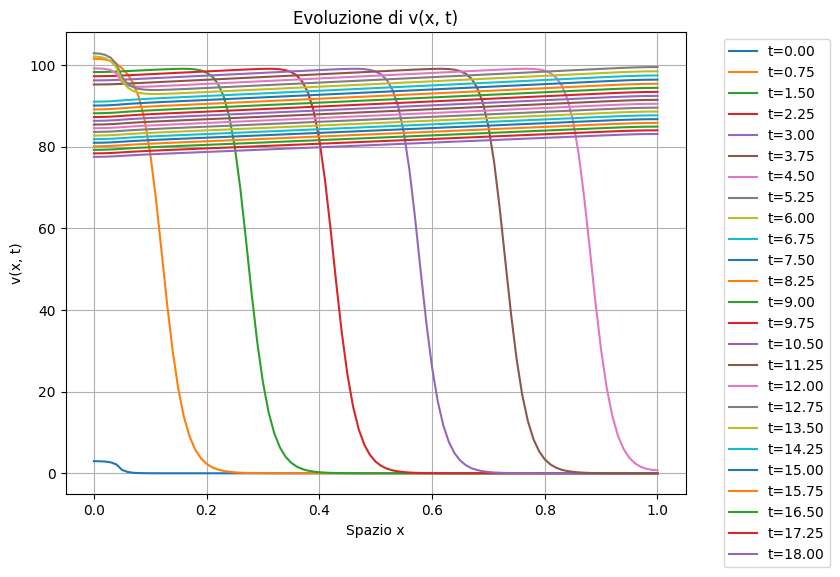

In [ ]:

# Matrice A approssima la derivata seconda (termine diffusivo)
A = np.zeros((n, n))
for i in range(1, n - 1):
    A[i, i] =  2 * alpha
    A[i, i - 1] = - alpha
    A[i, i + 1] = - alpha

# condizioni neumann : derivata nulla agli etsremi dle dominio 
# dvdx =  v1 - v0 / h  = 0 --> v1 = v0
A[0, 0] = alpha
A[-1, -1] =  alpha
A[0 , 1] = -alpha 
A[-1, -2] = - alpha

M = np.eye(n) 
M[0, 0] = 1 / 2
M[-1, -1] = 1 / 2
#M [0, 1] = M[-1, -2] = -1

# Sistema finale
J = M/tau +  A

# --------------------------------------------------------------------------------

v = np.zeros_like(x)
w = np.zeros_like(v)  

'''
# Funzione per I_app(x, t) 1 stimolo
def I_app(x, t):
    I = np.zeros_like(x)
    if 0 <= t <= 1:
        I[(x >= 0) & (x <= 0.4)] = 100  # Stimolo iniziale a sinistra
    return I
'''
'''
# 2 stimoli 
def I_app_2 (x, t):
    I = np.zeros_like(x)
    if 0 <= t <= 1:
        I[(x >= 0) & (x <= 0.35)] = 10  # Stimolo sinistro
        I[(x >= 0.96) & (x <= 1)] = 50  # Stimolo destro
    return I
'''
t2 = [12, 13, 14, 15]

def I_app_2(x, t):
    I = np.zeros_like(x)  
    if 0 <= t <= 2: 
        I[(x >= 0) & (x <= 0.04)] = 60  

    for i in t2:
        if i <= t <= i + 2:
            I[(x >= 0) & (x <= 0.04)] = 100
    return I


def F(v, w):
    return (- g * v * (1- v/vth) * (1 - v/vp) - mu1*v*w)
#b * v * (v - beta) * (delta - v) - c * w

def G(v, w):
    return  mu2 * (v/vp - w)
#epsilon * (v - gamma * w)


# Simulazione temporale
v_all = []

for step, current_time in enumerate(t):
    reaction = F(v, w)+ I_app_2(x, current_time)
    rhs_v = (1 / tau) * M @ v + M @ reaction
  
    v_new =  np.linalg.solve(J, rhs_v)  #rislve il sistema J * x  = rhs_v 
    w_new = w +  tau * G(v_new, w) 

    v, w = v_new, w_new

    if step % int(len(t) / 25) == 0:
        v_all.append(v.copy())

plt.figure(figsize=(8, 6))
for i, v_snapshot in enumerate(v_all):
    plt.plot(x, v_snapshot, label=f"t={i * tau * 15:.2f}")
plt.xlabel("Spazio x")
plt.ylabel("v(x, t)")
plt.title("Evoluzione di v(x, t)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid()
plt.show()

## commento
# i fornti d'onda compaiono , ma l'intensità nè la posizione x<0.04 sono corretti. 
# non ho calcolato CV per questo motivo. Sembrano avere stessa dinamica. 
# ho ridotto T e di conseguenza anche i t2. perché richiedevano circa 3min per runnare ogni volta 

In [3]:
A = np.zeros((n, n))
for i in range(1, n - 1):
    A[i, i] =  2 * alpha
    A[i, i - 1] = - alpha
    A[i, i + 1] = - alpha

# condizioni neumann : derivata nulla agli etsremi dle dominio 
# dvdx =  v1 - v0 / h  = 0 --> v1 = v0
A[0, 0] = alpha
A[-1, -1] =  alpha
A[0 , 1] = -alpha 
A[-1, -2] = - alpha

A

array([[ 10., -10.,   0., ...,   0.,   0.,   0.],
       [-10.,  20., -10., ...,   0.,   0.,   0.],
       [  0., -10.,  20., ...,   0.,   0.,   0.],
       ...,
       [  0.,   0.,   0., ...,  20., -10.,   0.],
       [  0.,   0.,   0., ..., -10.,  20., -10.],
       [  0.,   0.,   0., ...,   0., -10.,  10.]])

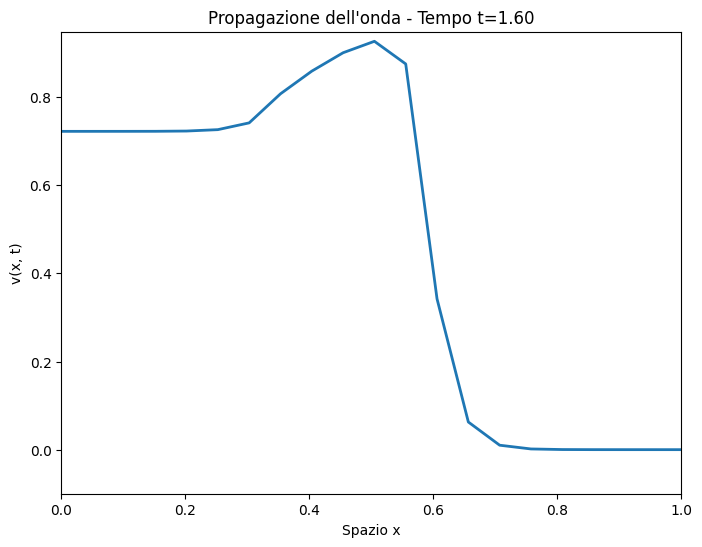

In [17]:
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter

# Creazione della figura
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 1)  # Limiti spaziali
ax.set_ylim(-0.1, np.max([np.max(v) for v in v_all]))  # Limiti dei valori di v
ax.set_xlabel("Spazio x")
ax.set_ylabel("v(x, t)")
ax.set_title("Propagazione dell'onda nel tempo")

# Funzione per inizializzare l'animazione
def init():
    line.set_data([], [])
    return line,

# Funzione per aggiornare ogni frame
def update(frame):
    line.set_data(x, v_all[frame])
    ax.set_title(f"Propagazione dell'onda - Tempo t={frame * tau * 200:.2f}")  # Correzione del tempo
    return line,

# Creazione dell'animazione
ani = FuncAnimation(
    fig, update, frames=len(v_all), init_func=init, interval=200, blit=True
)

# Salvataggio della GIF
ani.save("animazione.gif", writer=PillowWriter(fps=10))  # Riduci fps per rallentare

# Mostra l'animazione
plt.show()
